In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

print('Toate librariile au fost importate cu succes!')

Toate librariile au fost importate cu succes!


In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
coloane = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
           'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv(url, header=None, names=coloane)

print(f'Dimensiunea setului de date: {df.shape[0]} linii x {df.shape[1]} coloane')
df.head()

Dimensiunea setului de date: 4177 linii x 9 coloane


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


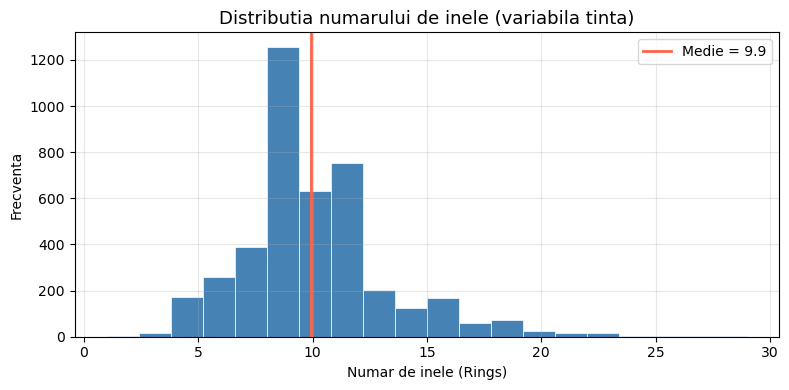

Medie: 9.93 | Min: 1 | Max: 29


In [3]:
# Distributia variabilei tinta
plt.figure(figsize=(8, 4))
plt.hist(df['Rings'], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Distributia numarului de inele (variabila tinta)', fontsize=13)
plt.xlabel('Numar de inele (Rings)')
plt.ylabel('Frecventa')
plt.axvline(df['Rings'].mean(), color='tomato', lw=2,
            label=f'Medie = {df["Rings"].mean():.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Medie: {df["Rings"].mean():.2f} | Min: {df["Rings"].min()} | Max: {df["Rings"].max()}')

In [4]:
# One-hot encoding pentru coloana 'Sex'
# 'M' devine [1,0,0], 'F' devine [0,1,0], 'I' devine [0,0,1]

df_encoded = pd.get_dummies(df, columns=['Sex'])

# Separam caracteristicile (X) de tinta (y)
X = df_encoded.drop(columns=['Rings']).values
y = df_encoded['Rings'].values.astype(float)

print(f'X (intrari): {X.shape}')
print(f'y (tinta)  : {y.shape}')

X (intrari): (4177, 10)
y (tinta)  : (4177,)


In [5]:
# Etapa I impartire date: 60% antrenare, 40% temporar pentru etapa a II-a
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=42
)

# Etapa II impartire date temporare in 20% validare si 20% testare
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print('Impartirea datelor:')
print(f'  Antrenare : {X_train.shape[0]} exemple  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Validare  : {X_val.shape[0]}  exemple  ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'  Testare   : {X_test.shape[0]}  exemple  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  TOTAL     : {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]} exemple')

Impartirea datelor:
  Antrenare : 2506 exemple  (60%)
  Validare  : 835  exemple  (20%)
  Testare   : 836  exemple  (20%)
  TOTAL     : 4177 exemple


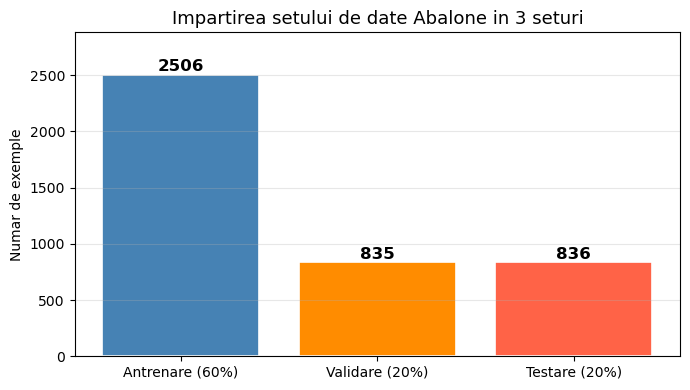

In [6]:
# Vizualizam impartirea
seturi = ['Antrenare (60%)', 'Validare (20%)', 'Testare (20%)']
dimensiuni = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
culori = ['steelblue', 'darkorange', 'tomato']

plt.figure(figsize=(7, 4))
bars = plt.bar(seturi, dimensiuni, color=culori, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, dimensiuni):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', fontsize=12, fontweight='bold')
plt.title('Impartirea setului de date Abalone in 3 seturi', fontsize=13)
plt.ylabel('Numar de exemple')
plt.ylim(0, max(dimensiuni) * 1.15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [7]:
# Standardizare date pe seturi de antrenare si validare
scaler = StandardScaler()

# fit_transform: invata parametrii si transforma doar datele de antrenare
X_train_s = scaler.fit_transform(X_train)

# transform: se aplica aceeasi transformare pe datele de validare si testare
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print('Standardizare aplicata corect pe toate cele 3 seturi.')
print(f'Medie train dupa scalare: {X_train_s[:, 0].mean():.4f}  (ideal: ~0)')
print(f'Std   train dupa scalare: {X_train_s[:, 0].std():.4f}   (ideal: ~1)')

Standardizare aplicata corect pe toate cele 3 seturi.
Medie train dupa scalare: -0.0000  (ideal: ~0)
Std   train dupa scalare: 1.0000   (ideal: ~1)


In [8]:
# Reteaua neuronala
retea = MLPRegressor(
    hidden_layer_sizes=(32, 16),     # 2 straturi ascunse cu ReLU
    activation='relu',               # functia de activare ReLU
    solver='adam',                   # algoritmul de optimizare
    max_iter=1000,                   # epoci maxime (suficient pentru convergenta)
    learning_rate_init=0.001,        # rata de invatare
    early_stopping=True,             # oprire automata cand nu mai progreseaza
    validation_fraction=0.1,         # 10% din train folosit intern pentru early stop
    n_iter_no_change=20,             # opreste dupa 20 epoci fara imbunatatire
    random_state=42
)

print('Se antreneaza reteaua...')
retea.fit(X_train_s, y_train)

print(f'Antrenament finalizat dupa {retea.n_iter_} epoci (din max 1000).')
print(f'Eroarea interna de antrenament: {retea.loss_:.4f}')

Se antreneaza reteaua...
Antrenament finalizat dupa 171 epoci (din max 1000).
Eroarea interna de antrenament: 2.1722


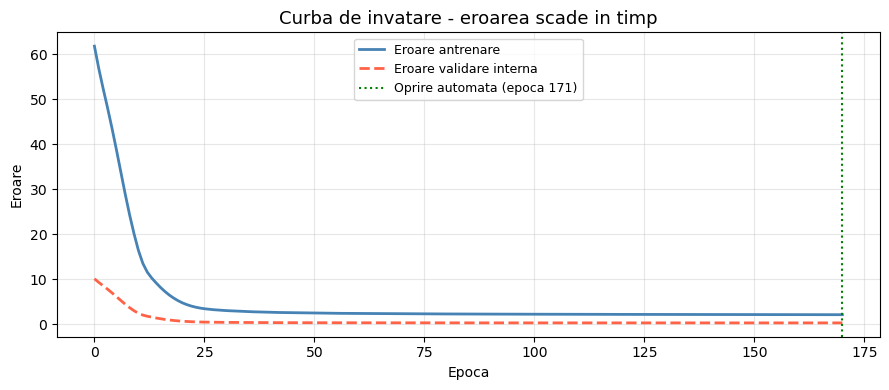

Interpretare:
  - Ambele curbe coboara: modelul generalizeaza bine
  - Train coboara, validare creste: OVERFITTING
  - Ambele raman mari: UNDERFITTING


In [9]:
# Vizualizare curba de invatare
plt.figure(figsize=(9, 4))
plt.plot(retea.loss_curve_, color='steelblue', lw=2, label='Eroare antrenare')

# Daca early_stopping=True, sklearn salveaza si scorul de validare interna
if hasattr(retea, 'validation_scores_') and retea.validation_scores_ is not None:
    # validation_scores_ este R2, il transformam in eroare (1 - R2) pentru comparatie
    val_loss = [1 - s for s in retea.validation_scores_]
    plt.plot(val_loss, color='tomato', lw=2, ls='--', label='Eroare validare interna')

plt.axvline(retea.n_iter_ - 1, color='green', lw=1.5, ls=':',
            label=f'Oprire automata (epoca {retea.n_iter_})')
plt.title('Curba de invatare - eroarea scade in timp', fontsize=13)
plt.xlabel('Epoca')
plt.ylabel('Eroare')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Interpretare:')
print('  - Ambele curbe coboara: modelul generalizeaza bine')
print('  - Train coboara, validare creste: OVERFITTING')
print('  - Ambele raman mari: UNDERFITTING')

In [10]:
# Performanta pe setul de VALIDARE
y_pred_val = retea.predict(X_val_s)
mae_val = mean_absolute_error(y_val, y_pred_val)
r2_val  = r2_score(y_val, y_pred_val)

# Performanta pe setul de TESTARE (evaluare finala)
y_pred_test = retea.predict(X_test_s)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test  = r2_score(y_test, y_pred_test)

print('=' * 45)
print('  REZULTATE FINALE')
print('=' * 45)
print(f'  MAE Validare  : {mae_val:.4f} inele')
print(f'  MAE Testare   : {mae_test:.4f} inele')
print(f'  R2  Validare  : {r2_val:.4f}')
print(f'  R2  Testare   : {r2_test:.4f}')
print('=' * 45)
print(f'\nDiferenta MAE validare vs testare: {abs(mae_val - mae_test):.4f} inele')
print('(Diferenta mica = modelul generalizeaza bine)')

  REZULTATE FINALE
  MAE Validare  : 1.5211 inele
  MAE Testare   : 1.5167 inele
  R2  Validare  : 0.5621
  R2  Testare   : 0.5465

Diferenta MAE validare vs testare: 0.0044 inele
(Diferenta mica = modelul generalizeaza bine)


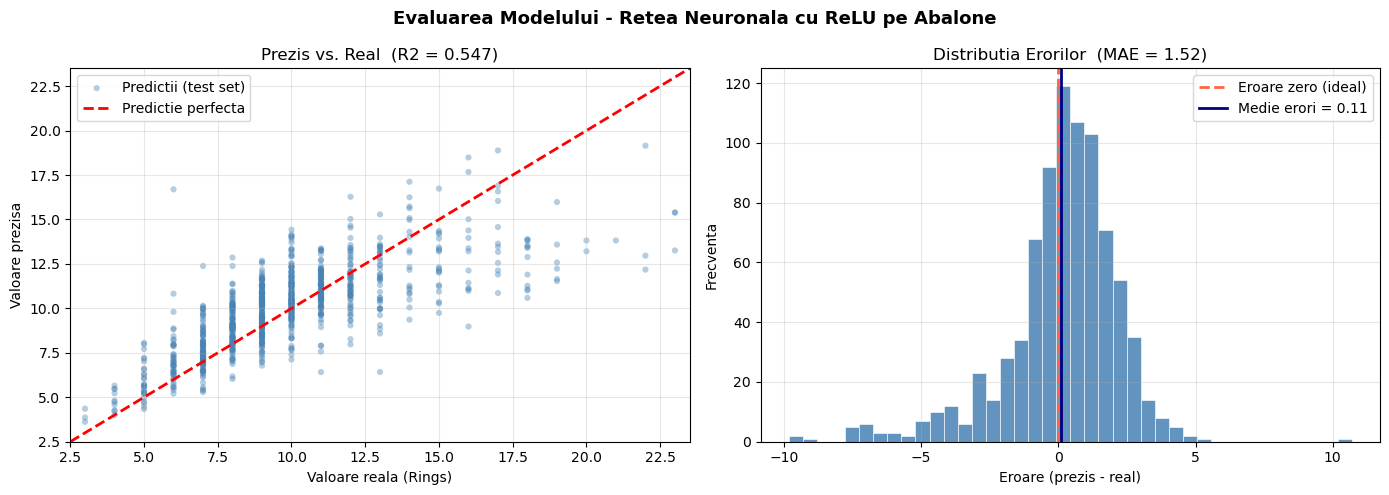

In [11]:
# Vizualizare rezultate pe setul de testare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluarea Modelului - Retea Neuronala cu ReLU pe Abalone',
             fontsize=13, fontweight='bold')

# Grafic 1: Prezis vs Real
ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.4, s=20,
            color='steelblue', edgecolors='none', label='Predictii (test set)')
minim = min(y_test.min(), y_pred_test.min()) - 0.5
maxim = max(y_test.max(), y_pred_test.max()) + 0.5
ax1.plot([minim, maxim], [minim, maxim], 'r--', lw=2, label='Predictie perfecta')
ax1.set_xlabel('Valoare reala (Rings)')
ax1.set_ylabel('Valoare prezisa')
ax1.set_title(f'Prezis vs. Real  (R2 = {r2_test:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(minim, maxim)
ax1.set_ylim(minim, maxim)

# Grafic 2: Distributia erorilor
ax2 = axes[1]
erori = y_pred_test - y_test
ax2.hist(erori, bins=40, color='steelblue', edgecolor='white',
         linewidth=0.5, alpha=0.85)
ax2.axvline(0, color='tomato', lw=2, ls='--', label='Eroare zero (ideal)')
ax2.axvline(erori.mean(), color='navy', lw=2,
            label=f'Medie erori = {erori.mean():.2f}')
ax2.set_xlabel('Eroare (prezis - real)')
ax2.set_ylabel('Frecventa')
ax2.set_title(f'Distributia Erorilor  (MAE = {mae_test:.2f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('abalone_regresie_final.png', dpi=130, bbox_inches='tight')
plt.show()

In [12]:
# Predictie pentru un abalone nou
abalone_nou = np.array([[0.55, 0.43, 0.14, 0.82, 0.35, 0.18, 0.22, 0, 0, 1]])
abalone_nou_s = scaler.transform(abalone_nou)
inele_prezise = retea.predict(abalone_nou_s)[0]

print('Caracteristici abalone nou:')
print('  Sex: Mascul | Lungime: 0.55 mm | Diametru: 0.43 mm | Greutate: 0.82 g')
print(f'\nPredictie model : {inele_prezise:.1f} inele')
print(f'Varsta estimata : {inele_prezise + 1.5:.1f} ani')

Caracteristici abalone nou:
  Sex: Mascul | Lungime: 0.55 mm | Diametru: 0.43 mm | Greutate: 0.82 g

Predictie model : 10.3 inele
Varsta estimata : 11.8 ani
